# Lasso Regression Demo: Projected GD, Coordinate Descent, SGD, and Proximal GD

In this notebook, we solve the sparse linear regression problem from four first-order viewpoints:

1. **Projected gradient descent (PGD)** for the **constrained** Lasso form
2. **Coordinate descent (CD)** for the **penalized** Lasso form
3. **Stochastic gradient method** using a **stochastic proximal/subgradient** update
4. **Proximal gradient descent (Prox-GD)** for the **penalized** Lasso form

We consider the two standard formulations:

$$
\text{Penalized Lasso:}\qquad
\min_{\theta \in \mathbb{R}^d}
\frac{1}{2n}\|y - X\theta\|_2^2 + \lambda \|\theta\|_1,
$$

and

$$
\text{Constrained Lasso:}\qquad
\min_{\theta \in \mathbb{R}^d}
\frac{1}{2n}\|y - X\theta\|_2^2
\quad\text{s.t.}\quad
\|\theta\|_1 \le \tau.
$$

To compare them on the same dataset, we will:
- solve the penalized Lasso with CD / Prox-GD / stochastic proximal GD,
- use the resulting solution to set
  $$
  \tau = \|\hat\theta\|_1,
  $$
  so that projected GD solves the corresponding constrained problem with a matched radius.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

## 1. Generate synthetic sparse regression data

We generate data from

$$
y = X\theta^\star + \varepsilon,
$$

where only a few entries of $\theta^\star$ are nonzero.


In [2]:
n = 120
d = 40

X = np.random.randn(n, d)

theta_true = np.zeros(d)
theta_true[[1, 7, 12, 20, 31]] = np.array([2.5, -1.8, 1.2, -2.2, 1.5])

noise = 0.8 * np.random.randn(n)
y = X @ theta_true + noise

print("n =", n, ", d =", d)
print("true support =", np.where(theta_true != 0)[0])

n = 120 , p = 40
true support = [ 1  7 12 20 31]


## 2. Visualize the true sparse theta vector

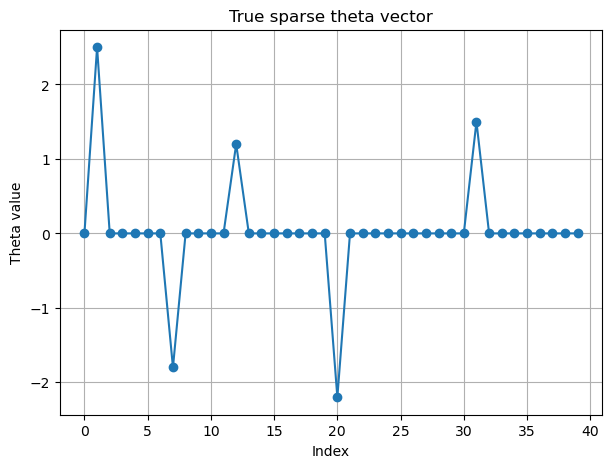

In [3]:
plt.figure(figsize=(7, 5))
plt.plot(theta_true, marker="o")
plt.xlabel("Index")
plt.ylabel("Theta value")
plt.title("True sparse theta vector")
plt.grid(True)
plt.show()

## 3. Common utilities

We standardize the design matrix and center the response so that the optimization routines are easier to compare.


In [4]:
def standardize_design(X, y):
    '''
    Standardize the columns of X and center y.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=0)
    X_std[X_std == 0.0] = 1.0

    y_mean = y.mean()

    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    stats = {
        "X_mean": X_mean,
        "X_std": X_std,
        "y_mean": y_mean,
    }
    return X_scaled, y_centered, stats


def recover_original_scale(theta_scaled, stats):
    '''
    Convert thetas in the standardized problem back to the original scale.
    '''
    theta_scaled = np.asarray(theta_scaled, dtype=float).reshape(-1)
    theta_orig = theta_scaled / stats["X_std"]
    intercept = stats["y_mean"] - stats["X_mean"] @ theta_orig
    return intercept, theta_orig


def predict_from_standardized_fit(X, theta_scaled, stats):
    '''
    Predict on the original X using a theta vector fitted on standardized data.
    '''
    intercept, theta_orig = recover_original_scale(theta_scaled, stats)
    return intercept + X @ theta_orig


def lasso_objective(X, y, theta, lam):
    '''
    Penalized Lasso objective:
        1/(2n) ||y - X theta||^2 + lam * ||theta||_1
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    resid = y - X @ theta
    return 0.5 / n * np.dot(resid, resid) + lam * np.linalg.norm(theta, ord=1)


def constrained_lasso_objective(X, y, theta):
    '''
    Smooth part only:
        1/(2n) ||y - X theta||^2
    for the constrained formulation.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    resid = y - X @ theta
    return 0.5 / n * np.dot(resid, resid)


def soft_threshold(x, t):
    '''
    Soft-thresholding operator.
    '''
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)


def lasso_gradient(X, y, theta):
    '''
    Gradient of the smooth part
        g(theta) = 1/(2n) ||y - X theta||^2.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    return (X.T @ (X @ theta - y)) / n


def estimate_lipschitz_constant(X):
    '''
    Lipschitz constant of grad g(theta) = (1/n) X^T (X theta - y):
        L = lambda_max(X^T X / n).
    '''
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    smax = np.linalg.norm(X, ord=2)
    return (smax ** 2) / n


X_scaled, y_centered, stats = standardize_design(X, y)
L = estimate_lipschitz_constant(X_scaled)

print("Estimated Lipschitz constant L =", L)

Estimated Lipschitz constant L = 2.1940119322682845


## 4. Coordinate descent for penalized Lasso

For
$$
\min_\theta \frac{1}{2n}\|y - X\theta\|_2^2 + \lambda \|\theta\|_1,
$$
coordinate descent updates one entry at a time and uses the scalar soft-threshold formula.


In [5]:
def lasso_coordinate_descent(X, y, lam, max_iter=5000, tol=1e-10):
    '''
    Solve penalized Lasso by cyclic coordinate descent.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    n, d = X.shape
    theta = np.zeros(d)
    r = y.copy()   # r = y - X theta

    col_sq_norm = np.sum(X ** 2, axis=0) / n
    loss_history = []

    for it in range(max_iter):
        theta_old = theta.copy()

        for j in range(d):
            if col_sq_norm[j] == 0.0:
                theta[j] = 0.0
                continue

            # put back the old contribution of coordinate j
            r = r + X[:, j] * theta[j]

            rho_j = np.dot(X[:, j], r) / n
            theta[j] = soft_threshold(rho_j, lam) / col_sq_norm[j]

            # remove the new contribution
            r = r - X[:, j] * theta[j]

        obj = lasso_objective(X, y, theta, lam)
        loss_history.append(obj)

        if np.linalg.norm(theta - theta_old) < tol:
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "n_iter": it + 1,
    }

In [6]:
lam = 0.15

res_cd = lasso_coordinate_descent(
    X_scaled,
    y_centered,
    lam=lam,
    max_iter=5000,
    tol=1e-10,
)

y_hat_cd = predict_from_standardized_fit(X, res_cd["theta"], stats)
mse_cd = mean_squared_error(y, y_hat_cd)

## 5. Result: Coordinate descent for penalized Lasso

Iterations          : 11
Final objective     : 1.6618831480381864
Prediction MSE      : 0.6804053044315966
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


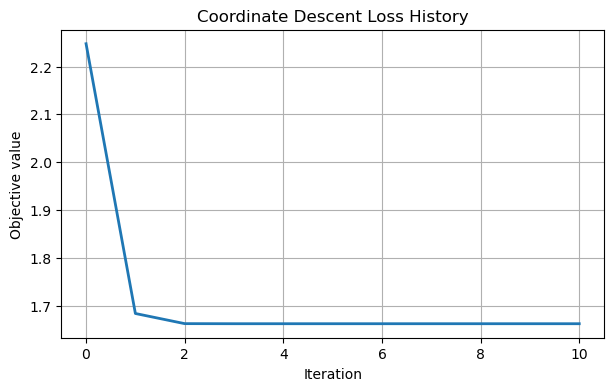

In [7]:
print("Iterations          :", res_cd["n_iter"])
print("Final objective     :", res_cd["loss_history"][-1])
print("Prediction MSE      :", mse_cd)
print("Estimated theta     :", res_cd["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_cd["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Coordinate Descent Loss History")
plt.grid(True)
plt.show()

## 5. Proximal gradient descent for penalized Lasso

We write the objective as
$$
F(\theta) = g(\theta) + h(\theta),
$$
where
$$
g(\theta) = \frac{1}{2n}\|y - X\theta\|_2^2,
\qquad
h(\theta) = \lambda \|\theta\|_1.
$$

Then the proximal gradient update is
$$
\theta^{t+1}
=
\operatorname{soft}\!\left(
\theta^t - \frac{1}{L}\nabla g(\theta^t),
\frac{\lambda}{L}
\right).
$$


In [8]:
def lasso_proximal_gradient(X, y, lam, step=None, max_iter=10000, tol=1e-10):
    '''
    Solve penalized Lasso by proximal gradient descent.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if step is None:
        L = estimate_lipschitz_constant(X)
        step = 1.0 / L

    d = X.shape[1]
    theta = np.zeros(d)
    loss_history = []

    for it in range(max_iter):
        theta_old = theta.copy()

        grad = lasso_gradient(X, y, theta)
        theta = soft_threshold(theta - step * grad, step * lam)

        obj = lasso_objective(X, y, theta, lam)
        loss_history.append(obj)

        if np.linalg.norm(theta - theta_old) < tol:
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "step": step,
        "n_iter": it + 1,
    }

In [9]:
res_pg = lasso_proximal_gradient(
    X_scaled,
    y_centered,
    lam=lam,
    max_iter=10000,
    tol=1e-10,
)

y_hat_pg = predict_from_standardized_fit(X, res_pg["theta"], stats)
mse_pg = mean_squared_error(y, y_hat_pg)

## 7. Result: Proximal gradient descent for penalized Lasso

Iterations          : 53
Step size           : 0.4557860352956912
Final objective     : 1.6618831480381866
Prediction MSE      : 0.6804053044555337
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


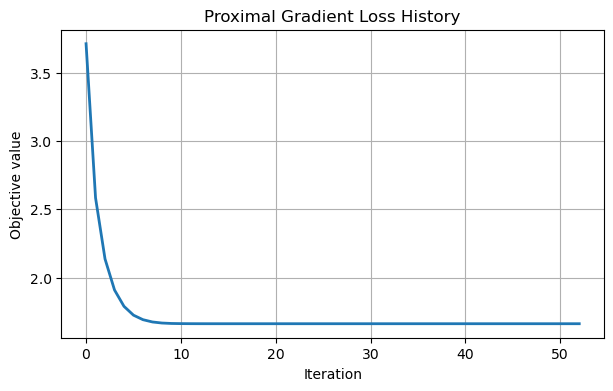

In [10]:
print("Iterations          :", res_pg["n_iter"])
print("Step size           :", res_pg["step"])
print("Final objective     :", res_pg["loss_history"][-1])
print("Prediction MSE      :", mse_pg)
print("Estimated theta     :", res_pg["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_pg["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Proximal Gradient Loss History")
plt.grid(True)
plt.show()

## 6. Stochastic proximal gradient / stochastic subgradient for penalized Lasso

Using one sample $(x_i, y_i)$ at a time, an unbiased stochastic gradient of the smooth part is

$$
\nabla g_i(\theta) = x_i (x_i^\top \theta - y_i).
$$

Then a stochastic proximal update is
$$
\theta^{t+1}
=
\operatorname{soft}\!\left(
\theta^t - \eta_t \nabla g_{i_t}(\theta^t),
\eta_t \lambda
\right).
$$

This is usually the cleanest SGD-style method for Lasso.


In [11]:
def lasso_stochastic_proximal_gradient(
    X,
    y,
    lam,
    epochs=200,
    eta0=0.2,
    decay=0.01,
    batch_size=1,
    random_state=0,
):
    '''
    Stochastic proximal gradient for penalized Lasso.
    If batch_size=1, this is the single-sample version.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    n, d = X.shape
    theta = np.zeros(d)
    loss_history = []

    total_steps = 0

    for epoch in range(epochs):
        perm = rng.permutation(n)

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xb = X[idx]
            yb = y[idx]

            grad_est = Xb.T @ (Xb @ theta - yb) / len(idx)

            eta_t = eta0 / np.sqrt(1.0 + decay * total_steps)
            theta = soft_threshold(theta - eta_t * grad_est, eta_t * lam)

            total_steps += 1

        loss_history.append(lasso_objective(X, y, theta, lam))

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "epochs": epochs,
        "total_steps": total_steps,
    }

In [22]:
res_spg = lasso_stochastic_proximal_gradient(
    X_scaled,
    y_centered,
    lam=lam,
    epochs=50,
    eta0=0.15,
    decay=0.05,
    batch_size=1,
    random_state=123,
)

y_hat_spg = predict_from_standardized_fit(X, res_spg["theta"], stats)
mse_spg = mean_squared_error(y, y_hat_spg)

## 9. Result: Stochastic proximal gradient for penalized Lasso

Epochs              : 50
Total steps         : 6000
Final objective     : 1.7204435707327135
Prediction MSE      : 0.6064957641025902
Estimated theta     : [ 0.032931  2.514192  0.017259 -0.007007 -0.02649  -0.054563  0.00297
 -1.670325 -0.        0.004195 -0.00525   0.000349  1.177212  0.023497
  0.       -0.009449  0.01919  -0.027202 -0.011228 -0.02771  -1.910215
  0.014642 -0.014713  0.02612  -0.001037  0.000371 -0.06671  -0.020295
  0.020913 -0.000601 -0.024688  1.523911  0.01999  -0.022706 -0.010239
 -0.080476  0.030311 -0.000895  0.003725  0.024393]


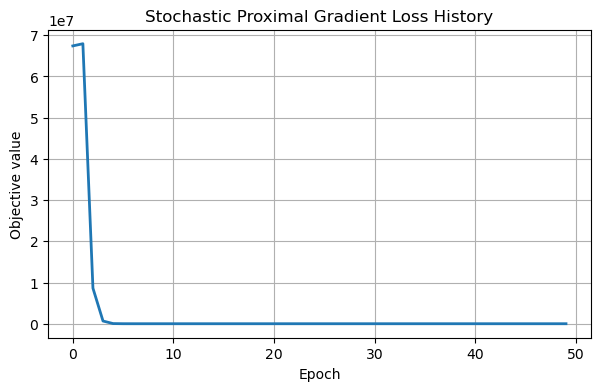

In [23]:
print("Epochs              :", res_spg["epochs"])
print("Total steps         :", res_spg["total_steps"])
print("Final objective     :", res_spg["loss_history"][-1])
print("Prediction MSE      :", mse_spg)
print("Estimated theta     :", res_spg["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_spg["loss_history"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Stochastic Proximal Gradient Loss History")
plt.grid(True)
plt.show()

## 7. Projected gradient descent for constrained Lasso

Projected GD applies directly to
$$
\min_\theta \frac{1}{2n}\|y - X\theta\|_2^2
\quad\text{s.t.}\quad
\|\theta\|_1 \le \tau.
$$

The update is
$$
\theta^{t+1}
=
\Pi_{\|\cdot\|_1 \le \tau}
\left(
\theta^t - \eta \nabla g(\theta^t)
\right),
$$
where $\Pi_{\|\cdot\|_1 \le \tau}$ is the Euclidean projection onto the $\\ell_1$ ball.


In [14]:
def project_onto_l1_ball(v, tau):
    '''
    Euclidean projection onto the l1-ball {x : ||x||_1 <= tau}.
    Reference idea: sorting-based projection.
    '''
    v = np.asarray(v, dtype=float).reshape(-1)

    if tau < 0:
        raise ValueError("tau must be nonnegative.")

    if np.linalg.norm(v, ord=1) <= tau:
        return v.copy()

    u = np.sort(np.abs(v))[::-1]
    cssv = np.cumsum(u)
    rho_candidates = u - (cssv - tau) / (np.arange(len(u)) + 1)
    rho = np.where(rho_candidates > 0)[0][-1]
    theta = (cssv[rho] - tau) / (rho + 1.0)

    return np.sign(v) * np.maximum(np.abs(v) - theta, 0.0)


def lasso_projected_gradient(X, y, tau, step=None, max_iter=10000, tol=1e-10):
    '''
    Solve constrained Lasso by projected gradient descent:
        min 1/(2n)||y - X theta||^2  s.t. ||theta||_1 <= tau.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if step is None:
        L = estimate_lipschitz_constant(X)
        step = 1.0 / L

    d = X.shape[1]
    theta = np.zeros(d)
    loss_history = []

    for it in range(max_iter):
        theta_old = theta.copy()

        grad = lasso_gradient(X, y, theta)
        theta = project_onto_l1_ball(theta - step * grad, tau)

        obj = constrained_lasso_objective(X, y, theta)
        loss_history.append(obj)

        if np.linalg.norm(theta - theta_old) < tol:
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "step": step,
        "tau": tau,
        "n_iter": it + 1,
    }

In [15]:
# Use a matched l1 radius from the penalized Lasso baseline
lasso_sk = Lasso(alpha=lam, fit_intercept=False, max_iter=100000, tol=1e-10)
lasso_sk.fit(X_scaled, y_centered)
theta_sklearn = lasso_sk.coef_
tau = np.linalg.norm(theta_sklearn, ord=1)

res_proj = lasso_projected_gradient(
    X_scaled,
    y_centered,
    tau=tau,
    max_iter=10000,
    tol=1e-10,
)

y_hat_proj = predict_from_standardized_fit(X, res_proj["theta"], stats)
y_hat_sk = predict_from_standardized_fit(X, theta_sklearn, stats)

mse_proj = mean_squared_error(y, y_hat_proj)
mse_sk = mean_squared_error(y, y_hat_sk)

print("lambda =", lam)
print("matched tau =", tau)

lambda = 0.15
matched tau = 8.811203305482588


## 11. Result: Projected gradient descent for constrained Lasso

Iterations          : 52
Constraint radius   : 8.811203305482588
Final objective     : 0.3402026522157983
Prediction MSE      : 0.6804053044315967
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


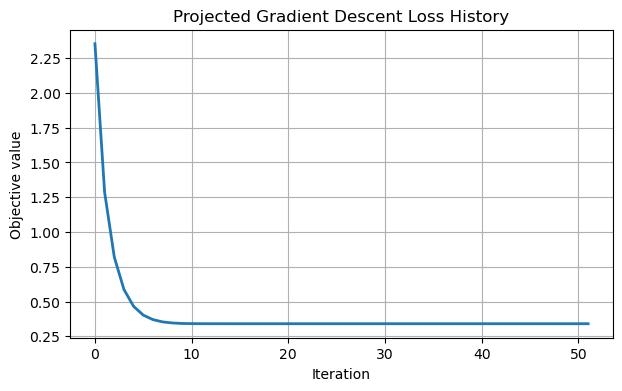

In [16]:
print("Iterations          :", res_proj["n_iter"])
print("Constraint radius   :", tau)
print("Final objective     :", res_proj["loss_history"][-1])
print("Prediction MSE      :", mse_proj)
print("Estimated theta     :", res_proj["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_proj["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Projected Gradient Descent Loss History")
plt.grid(True)
plt.show()

## 12. Final comparison of estimated $\theta$

In [17]:
print("True theta                    :", theta_true)
print("Coordinate descent theta      :", res_cd["theta"])
print("Proximal gradient theta       :", res_pg["theta"])
print("Stochastic proximal GD theta  :", res_spg["theta"])
print("Projected gradient theta      :", res_proj["theta"])
print("scikit-learn theta            :", theta_sklearn)

True theta                    : [ 0.   2.5  0.   0.   0.   0.   0.  -1.8  0.   0.   0.   0.   1.2  0.
  0.   0.   0.   0.   0.   0.  -2.2  0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   1.5  0.   0.   0.   0.   0.   0.   0.   0. ]
Coordinate descent theta      : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]
Proximal gradient theta       : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0

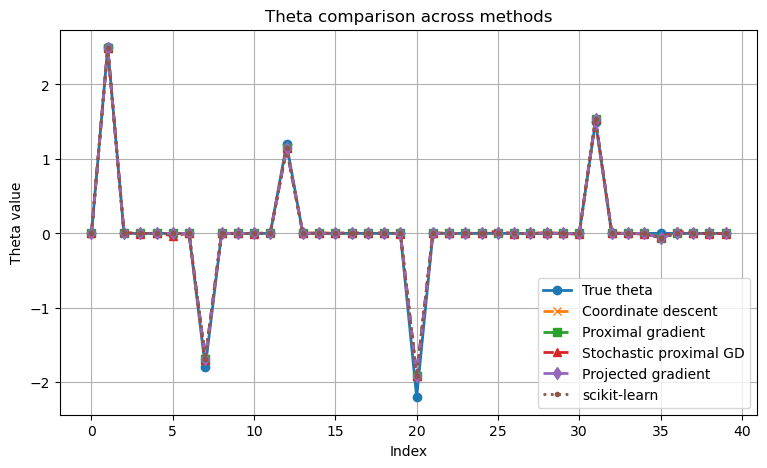

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(theta_true, marker="o", linewidth=2, label="True theta")
plt.plot(res_cd["theta"], marker="x", linestyle="--", linewidth=2, label="Coordinate descent")
plt.plot(res_pg["theta"], marker="s", linestyle="--", linewidth=2, label="Proximal gradient")
plt.plot(res_spg["theta"], marker="^", linestyle="--", linewidth=2, label="Stochastic proximal GD")
plt.plot(res_proj["theta"], marker="d", linestyle="--", linewidth=2, label="Projected gradient")
plt.plot(theta_sklearn, marker=".", linestyle=":", linewidth=2, label="scikit-learn")
plt.xlabel("Index")
plt.ylabel("Theta value")
plt.title("Theta comparison across methods")
plt.legend()
plt.grid(True)
plt.show()

## 13. Compare objective histories (first 50 iterations / epochs)

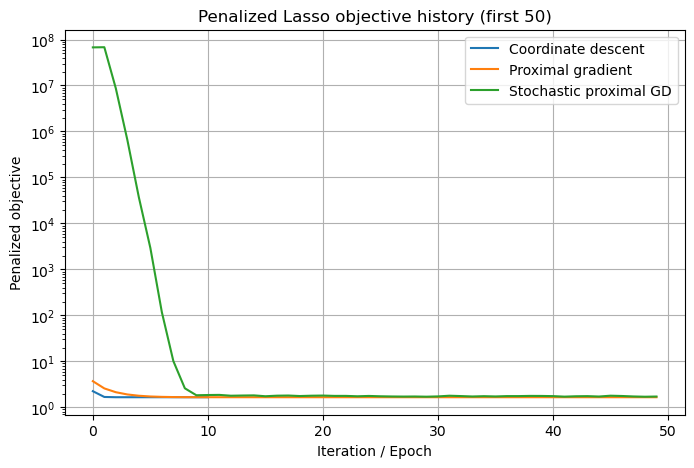

In [19]:
plt.figure(figsize=(8, 5))
k = 50
plt.plot(res_cd["loss_history"][:k], label="Coordinate descent")
plt.plot(res_pg["loss_history"][:k], label="Proximal gradient")
plt.plot(res_spg["loss_history"][:k], label="Stochastic proximal GD")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Penalized objective")
plt.title("Penalized Lasso objective history (first 50)")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

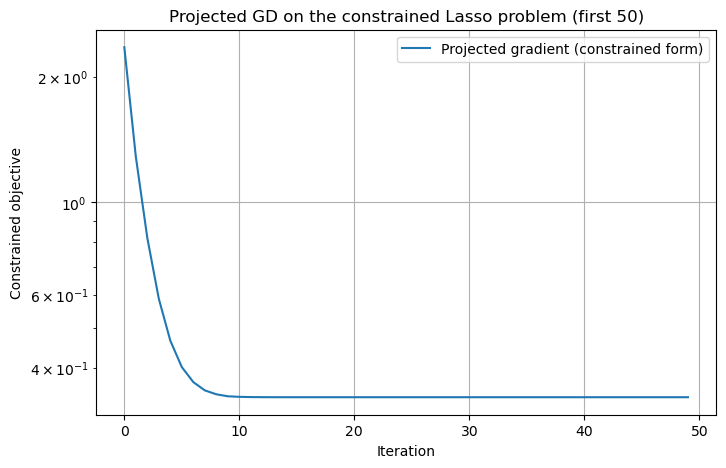

In [20]:
plt.figure(figsize=(8, 5))
k = 50
plt.plot(res_proj["loss_history"][:k], label="Projected gradient (constrained form)")
plt.xlabel("Iteration")
plt.ylabel("Constrained objective")
plt.title("Projected GD on the constrained Lasso problem (first 50)")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

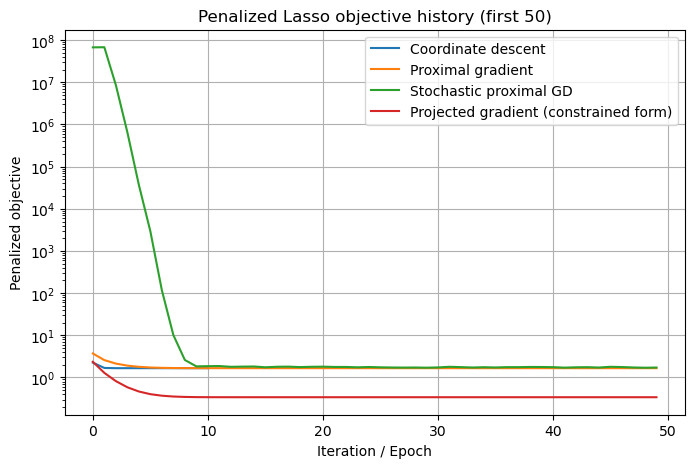

In [24]:
plt.figure(figsize=(8, 5))
k = 50
plt.plot(res_cd["loss_history"][:k], label="Coordinate descent")
plt.plot(res_pg["loss_history"][:k], label="Proximal gradient")
plt.plot(res_spg["loss_history"][:k], label="Stochastic proximal GD")
plt.plot(res_proj["loss_history"][:k], label="Projected gradient (constrained form)")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Penalized objective")
plt.title("Penalized Lasso objective history (first 50)")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

## 14. Final result comparison

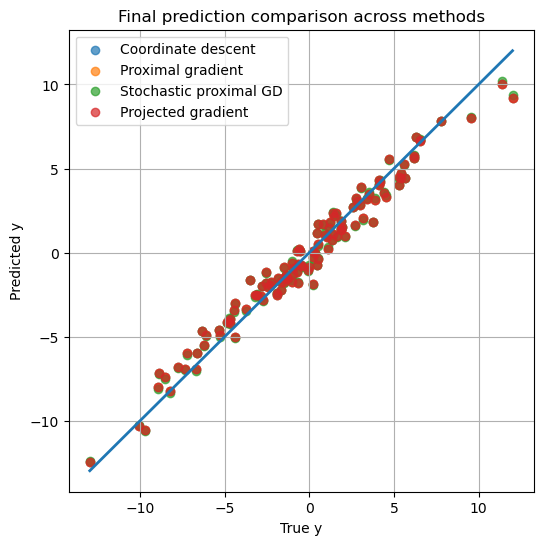

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y, y_hat_cd, alpha=0.7, label="Coordinate descent")
plt.scatter(y, y_hat_pg, alpha=0.7, label="Proximal gradient")
plt.scatter(y, y_hat_spg, alpha=0.7, label="Stochastic proximal GD")
plt.scatter(y, y_hat_proj, alpha=0.7, label="Projected gradient")
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Final prediction comparison across methods")
plt.grid(True)
plt.legend()
plt.show()

## Summary

- **Coordinate descent** and **proximal gradient** both solve the usual penalized Lasso directly.
- **Stochastic proximal gradient** is the natural SGD-style method for Lasso because of the nonsmooth $\\ell_1$ term.
- **Projected gradient descent** is better matched to the constrained form
  $
  \|\theta\|_1 \le \tau.
  $
